# Evaluating the genre model

Rerun this after every change to `build_dataset.py`, `features.py` or `train.py`. It scores the model the ml
service loads (`models/genre_classifier.keras`), checks the data still looks right, shows where the model goes
wrong, and adds one line to `runs.csv` so each run can be compared with the last.

Order: `python build_dataset.py`, `python train.py`, then Run All here.

## Settings

In [1]:
from pathlib import Path

MODEL_PATH = Path("models/genre_classifier.keras")  # the file app.py serves
SPLIT = "test"      # "test" for real scores; "train" only to check for overfitting
SHOW_WRONG = 12     # how many of the most confident mistakes to show as thumbnails

## Load the model and the photos

`load_split` reads `data/dataset.csv`, which `build_dataset.py` writes. The image names are read separately,
in the same row order, so mistakes can be shown as photos later.

In [2]:
import csv
import math
import subprocess
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, cohen_kappa_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from dataset import DATA_DIR, DATASET_PATH, IMAGES_DIR, load_labels, load_split
from genres import GENRES

model = tf.keras.models.load_model(MODEL_PATH)
model.summary()

x_train, y_train = load_split("train")
x_eval, y_eval = load_split(SPLIT)
with DATASET_PATH.open(newline="") as file:
    image_names = [row["image"] for row in csv.DictReader(file) if row["split"] == SPLIT]

# One row of 4 probabilities per photo, in GENRES order. argmax is the model's guess.
probabilities = model.predict(x_eval, verbose=0)
predicted = probabilities.argmax(axis=1)
confidence = probabilities.max(axis=1)

print(f"{len(y_train)} training photos, {len(y_eval)} {SPLIT} photos, {x_eval.shape[1]} features each")

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_20                │ (None, 8)              │            17 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,007 (58.63 KB)

 Trainable params: 4,996 (19.52 KB)

 Non-trainable params: 17 (72.00 B)

 Optimizer params: 9,994 (39.04 KB)

2362 training photos, 591 test photos, 8 features each


## Sanity checks

These catch a broken dataset or model before the scores below are trusted. Each one stops the notebook if it
fails.

In [3]:
# features.py and cpp-core/src/ImageFeatures.cpp both scale every feature to 0..1.
assert x_eval.min() >= 0 and x_eval.max() <= 1, "a feature is outside 0..1"
assert len(image_names) == len(y_eval), "dataset.csv rows and the split are out of step"

# The softmax layer in train.py should make each row sum to 1.
assert np.allclose(probabilities.sum(axis=1), 1, atol=1e-4), "probabilities don't sum to 1"

# A model that never guesses one genre has collapsed, whatever its accuracy says.
never_guessed = [GENRES[i] for i in range(len(GENRES)) if i not in predicted]
assert not never_guessed, f"never predicted: {never_guessed}"

print(f"{'genre':<11} {'labels':>6} {'guesses':>8}")
for i, genre in enumerate(GENRES):
    print(f"{genre:<11} {np.sum(y_eval == i):>6} {np.sum(predicted == i):>8}")
print("all checks passed")

genre       labels  guesses
EDM_CHILL      114      106
EDM_DROP        83       69
CINEMATIC      215      226
HOUSE          179      190
all checks passed


## Headline numbers

Top-2 counts a photo as right when its label is one of the model's two most likely genres. The baselines are
always guessing the most common training genre, and logistic regression on the same 8 features.
The intervals come from resampling the photos 10,000 times; the fixed seed keeps them the same between runs of
the same model.

In [ ]:
most_common = np.full_like(y_eval, np.bincount(y_train).argmax())
logistic = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(x_train, y_train)

# 1 for a right answer, 0 for a wrong one, per photo. Means of these are accuracies.
top1_right = (predicted == y_eval).astype(float)
top2_right = (np.argsort(probabilities, axis=1)[:, -2:] == y_eval[:, None]).any(axis=1).astype(float)
logistic_right = (logistic.predict(x_eval) == y_eval).astype(float)
most_common_right = (most_common == y_eval).astype(float)

# Each row of resamples is one bootstrap sample: len(y_eval) photo positions drawn with replacement.
resamples = np.random.default_rng(42).integers(0, len(y_eval), size=(10_000, len(y_eval)))

def interval(per_photo: np.ndarray) -> str:
    """The mean of a per-photo score, with its 95% bootstrap interval."""
    low, high = np.percentile(per_photo[resamples].mean(axis=1), [2.5, 97.5])
    return f"{per_photo.mean():6.1%}   95% interval {low:.1%} to {high:.1%}"

print("Most common genre           ", interval(most_common_right))
print("Logistic regression         ", interval(logistic_right))
print("Network, top-1              ", interval(top1_right))
print("Network, top-2              ", interval(top2_right))
print("Network lead over logistic  ", interval(top1_right - logistic_right))

Most common genre             36.4%   95% interval 32.7% to 40.3%


Logistic regression           78.5%   95% interval 75.1% to 81.7%
Network, top-1                80.9%   95% interval 77.7% to 84.1%
Network, top-2                95.6%   95% interval 93.9% to 97.1%
Network lead over logistic     2.4%   95% interval 0.0% to 4.7%


## Per genre

In [5]:
print(classification_report(y_eval, predicted, target_names=GENRES, digits=3, zero_division=0))

              precision    recall  f1-score   support

   EDM_CHILL      0.811     0.754     0.782       114
    EDM_DROP      0.884     0.735     0.803        83
   CINEMATIC      0.796     0.837     0.816       215
       HOUSE      0.795     0.844     0.818       179

    accuracy                          0.809       591
   macro avg      0.822     0.793     0.805       591
weighted avg      0.811     0.809     0.808       591



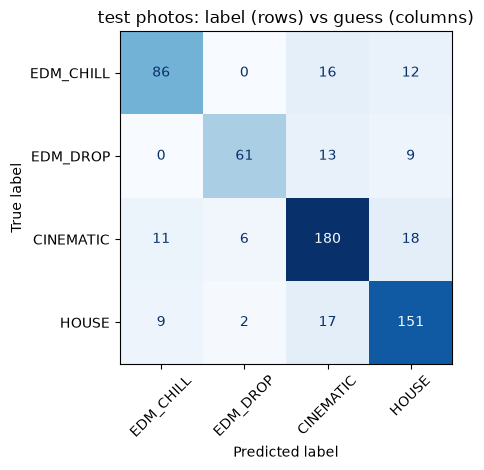

In [6]:
# Rows are the label, columns the guess, so the diagonal is the right answers.
ConfusionMatrixDisplay.from_predictions(y_eval, predicted, display_labels=GENRES,
                                        xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title(f"{SPLIT} photos: label (rows) vs guess (columns)")
plt.tight_layout()
plt.show()

## Confidence

The ml service returns the top probability as `confidence`, and the app shows it next to the genre. It is only
worth showing if high confidence really means the model is more often right.

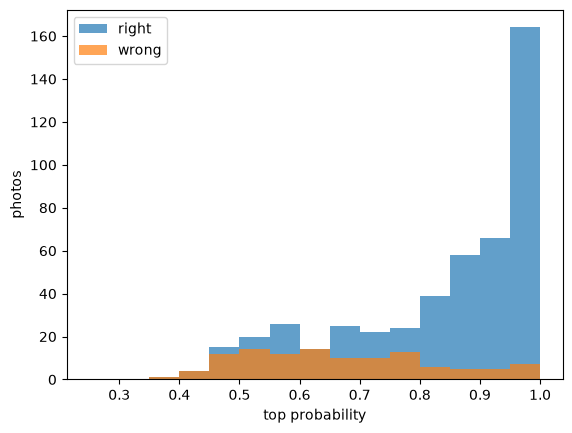

cutoff   kept  accuracy
   0.0   100%     80.9%
   0.5    94%     82.7%
   0.6    82%     85.5%
   0.7    71%     89.0%
   0.8    59%     93.4%
   0.9    41%     95.0%


In [7]:
right = predicted == y_eval
bins = np.linspace(0.25, 1, 16)  # 0.25 is the lowest a top probability out of 4 genres can be
plt.hist(confidence[right], bins=bins, alpha=0.7, label="right")
plt.hist(confidence[~right], bins=bins, alpha=0.7, label="wrong")
plt.xlabel("top probability")
plt.ylabel("photos")
plt.legend()
plt.show()

# Accuracy on only the photos the model is at least this sure about, and how many photos that keeps.
print(f"{'cutoff':>6} {'kept':>6} {'accuracy':>9}")
for cutoff in [0.0, 0.5, 0.6, 0.7, 0.8, 0.9]:
    kept = confidence >= cutoff
    print(f"{cutoff:>6.1f} {kept.mean():>6.0%} {right[kept].mean():>9.1%}")

## The most confident mistakes

Wrong guesses sorted by how sure the model was. Looking at the photos shows whether the label, the features or
the model is to blame.

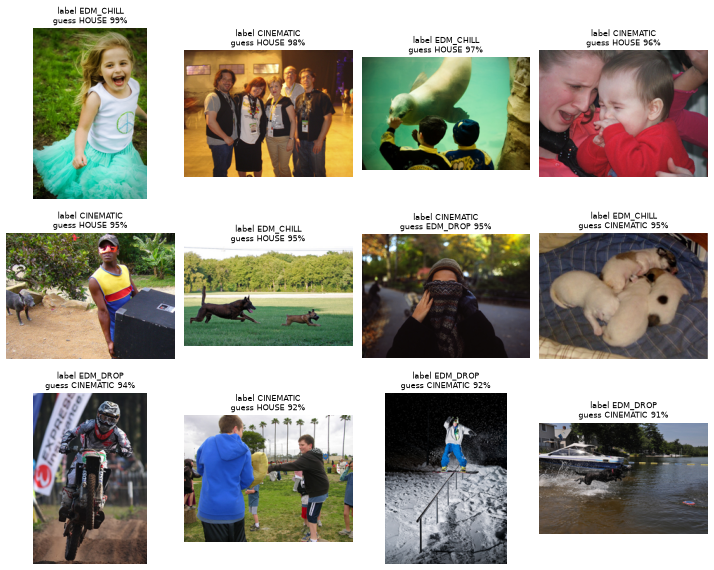

In [8]:
wrong = np.flatnonzero(~right)
worst = wrong[np.argsort(-confidence[wrong])][:SHOW_WRONG]

columns = 4
rows = math.ceil(len(worst) / columns)
figure, axes = plt.subplots(rows, columns, figsize=(3 * columns, 3.2 * rows), dpi=60, squeeze=False)
for axis in axes.flat:
    axis.axis("off")
for axis, i in zip(axes.flat, worst):
    photo = Image.open(IMAGES_DIR / image_names[i])
    photo.thumbnail((240, 240))  # small copies keep the saved notebook from growing by megabytes
    axis.imshow(photo)
    axis.set_title(f"label {GENRES[y_eval[i]]}\nguess {GENRES[predicted[i]]} {confidence[i]:.0%}", fontsize=9)
plt.tight_layout()
plt.show()

## Label consistency

149 random photos were labelled a second time (`data/second_labels.csv`). How
often the two agree is a rough ceiling for any model trained on these labels. Kappa corrects the agreement for
what two random guessers would reach by chance.

In [9]:
labels = load_labels()
with (DATA_DIR / "second_labels.csv").open(newline="") as file:
    second = {row["image"]: row["genre"] for row in csv.DictReader(file)}

first_labels = [labels[image] for image in second]
second_labels = list(second.values())
agreement = accuracy_score(first_labels, second_labels)
kappa = cohen_kappa_score(first_labels, second_labels)
print(f"{len(second)} photos with two labels: agreement {agreement:.1%}, Cohen's kappa {kappa:.2f}")

149 photos with two labels: agreement 74.5%, Cohen's kappa 0.64


## Run log

Each run appends one line to `runs.csv`. The commit says which code produced the model; `+changes` means files
in ml/ other than this notebook and the log were edited but not committed yet.

In [10]:
RUNS_PATH = Path("runs.csv")

commit = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True).stdout.strip()
# git diff --quiet exits with 1 when there are uncommitted changes. ":!name" leaves a file out,
# since this notebook and the log change on every run.
if subprocess.run(["git", "diff", "--quiet", "HEAD", "--", ".", ":!evaluate.ipynb", ":!runs.csv"]).returncode:
    commit += "+changes"

run = {"date": date.today().isoformat(), "commit": commit, "split": SPLIT,
       "top1": f"{top1_right.mean():.3f}", "top2": f"{top2_right.mean():.3f}",
       "logistic": f"{logistic_right.mean():.3f}"}

new_file = not RUNS_PATH.exists()
with RUNS_PATH.open("a", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=list(run))
    if new_file:
        writer.writeheader()
    writer.writerow(run)

with RUNS_PATH.open(newline="") as file:
    for row in list(csv.DictReader(file))[-5:]:
        print("  ".join(f"{key} {value}" for key, value in row.items()))

date 2026-09-30  commit 53b5ba6  split test  top1 0.809  top2 0.956  logistic 0.785


## Conclusions

From the run logged above, on the 591 test photos:

- The network gets 80.9% right (77.7% to 84.1%), and the label is in its top two 95.6% of the time.
- The two label sets agree on 74.5% of the 149 double-labelled photos (kappa 0.64). The model already agrees
  with the first labels more often than that, so more tuning of the network on these labels has little room left.
- Confidence means something: photos the model is at least 0.8 sure about are 59% of the set and 93.4% right.
  Wrong guesses are spread evenly between 0.45 and 0.8, while right ones pile up above 0.9.
- Most mistakes involve CINEMATIC or HOUSE. EDM_CHILL and EDM_DROP are never mistaken for each other.
- The most confident mistakes are mostly about what is in the photo, not its colours: action shots labelled
  EDM_DROP (motocross, snowboarding) guessed CINEMATIC, and bright outdoor or party photos guessed HOUSE. Average
  colour can't see that, so the next gain would come from better features, such as colour per region of the
  image or a pretrained image embedding.